In [1]:
from utils import (
    load_session_dumps,
    build_session_summary,
    preprocess_dumps,
    flag_outlier_dumps,
    vlsr_correction,
    build_overlap_grid,
    build_lsr_pairs,
    flag_outlier_pairs,
    combine_viable_pairs,
    assemble_W_R_arrays,
)
from plotters import (
    plot_survey_mollweide,
    plot_survey_mollweide_gridded,
)
from ugradiolab import plotting
from ugradiolab.plotting import SS_MICRO, SS_FINE

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
HPBW_DEG = 3.4
# NBLOCKS * NSAMPLES / fs (post-rewrite main pipeline)
INT_TIME_S = 1025 * 16384 / SAMPLE_RATE_HZ  # ~5.25 s

# --- RFI channel flagger (applied to both pols) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter ---
SHAPE_DEV_THRESH = 0.05
SHAPE_FRAC_THRESH = 0.05
SHAPE_MIN_GROUP_SIZE = 3

# --- Frequency switching ---
EDGE_TRIM_MHZ = 0.256

# --- Cross-session pair filter (on dimensionless R) ---
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.15
MIN_VIABLE_PAIRS = 3
PAIR_SPECTRUM_KEY = 'R_lsr'

# --- Paths / display ---
DATA_DIRS = [Path('data/main'), Path('data/nps')]
STATE_PATH = Path('artifacts/scan_load_state.pkl')
MOLL_CENTER_L = 120.0

get_ipython().run_line_magic('matplotlib', 'inline')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps (science pointings)

Loads science (survey) pointings only. Recal-pointing dumps live in the
same session trees but are handled independently in
`main_scan_calibration.ipynb` (T_cal anchor + drift solve), so they are
skipped here via `skip_recal=True`.

In [2]:
records = load_session_dumps(DATA_DIRS, skip_recal=True)
sessions = sorted({r['session'] for r in records})

display(build_session_summary(records, INT_TIME_S))

n_sci = sum(1 for r in records if not r['noise_on'])
n_cal = sum(1 for r in records if r['noise_on'])
lo_unique = sorted({r['lo_mhz'] for r in records if not r['noise_on']})
print(f'Science: {len(records)} dumps ({n_sci} obs, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-14 01:56,2026-05-14 02:40,44.0,24,288,57.3
1,main/session_002,2026-05-14 07:34,2026-05-14 09:35,121.0,63,756,54.7
2,main/session_003,2026-05-14 09:41,2026-05-14 12:14,153.3,82,984,56.1
3,main/session_004,2026-05-14 12:32,2026-05-14 15:16,163.3,83,996,53.4
4,main/session_005,2026-05-14 15:23,2026-05-14 17:56,153.8,79,948,53.9
5,main/session_006,2026-05-14 18:05,2026-05-14 20:03,118.1,56,672,49.8
6,main/session_007,2026-05-14 20:14,2026-05-14 23:20,186.0,72,864,40.6
7,main/session_008,2026-05-14 23:27,2026-05-15 02:08,160.7,82,984,53.6
8,main/session_009,2026-05-15 02:19,2026-05-15 03:31,72.6,38,456,54.9
9,main/session_016,2026-05-15 08:15,2026-05-15 10:59,163.7,82,984,52.6


Science: 22674 dumps (15114 obs, 7560 cal), 46 sessions, LO: [1419.86, 1421.14]


## 2. fftshift + RFI flagging + outlier dump filter

Per-pol RFI is flagged on both `corr00` and `corr11` independently, then
the science alias `stokes_I = corr00 + corr11` is set on each record.
HI is unpolarised, so summing the two linear-feed auto-correlations
yields true Stokes I with ~sqrt(2) SNR gain over a single pol. Channels
NaN in either pol propagate to NaN in the sum (a half-flagged channel
would be biased low, so this is the right behaviour).

The cal-side concern about pol 0 at 3.2 MHz (T_cal coupling) is a
calibration accuracy issue and does not affect the dimensionless ratio
R, which this notebook produces -- so both pols feed the canonical R.

In [3]:
n_rfi = preprocess_dumps(
    records,
    rfi_window=RFI_WINDOW,
    rfi_sigma=RFI_SIGMA,
    rfi_degree=RFI_CHEB_DEGREE,
    rfi_sample_frac=RFI_SAMPLE_FRAC,
    rfi_extrema_order=RFI_EXTREMA_ORDER,
)
print(f'Science: RFI flagged {n_rfi} channel samples '
      f'across {len(records)} dumps (both pols)')

sci_out = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
print(f'Outlier dump filter: removed {len(sci_out)} science '
      f'(>{SHAPE_FRAC_THRESH:.0%} channels deviate >{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {len(records)} science dumps')

Science: RFI flagged 161620 channel samples across 22674 dumps (both pols)
Outlier dump filter: removed 0 science (>5% channels deviate >5% from group median)
Remaining: 22674 science dumps


## 3. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.


In [4]:
grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']
v_overlap = grid['v_overlap']
dv_kms = grid['dv_kms']

print(f'LO pair: ({F1_MHZ}, {F2_MHZ}) MHz')
print(f"Overlap: [{grid['f_overlap_lo']:.2f}, {grid['f_overlap_hi']:.2f}] MHz")
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')


LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.660 km/s per channel


## 4. LSR correction, cross-session pair filter, combine

No temperature calibration is applied. All downstream spectra are the
dimensionless frequency-switched ratio R(v_LSR) of total intensity
(Stokes I = corr00 + corr11). Pair filtering and the integrated maps
all operate in R-space.

The pipeline builds per-pair Stokes-I R for each cell, LSR-shifts onto
a common grid, rejects outlier pairs via population MAD, and averages
the survivors.

Recal pointings are handled separately by `main_scan_calibration.ipynb`.
Neighbour-based QA on the resulting cell spectra is performed in
`main_scan_qa.ipynb`, which loads `artifacts/scan_load_state.pkl`.

In [5]:
print('Building LSR-corrected per-pair R for science cells...')
cell_pairs, obs_dumps_by_cell, v_lsr_overlap, mean_vcorr = build_lsr_pairs(
    records,
    lo1=F1_MHZ, lo2=F2_MHZ,
    overlap_mask=overlap_mask,
    v_overlap=v_overlap,
    vlsr_correction_fn=vlsr_correction,
)
print(f'Mean v_corr = {mean_vcorr:.2f} km/s -- '
      f'LSR velocity range: [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

n_pairs_total = sum(len(v) for v in cell_pairs.values())
viable_pairs_per_cell, flagged_pair_records = flag_outlier_pairs(
    cell_pairs,
    n_sigma=PAIR_NSIGMA,
    frac_thresh=PAIR_FRAC_THRESH,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Pair filter (on {PAIR_SPECTRUM_KEY}): flagged '
      f'{len(flagged_pair_records)}/{n_pairs_total} pairs '
      f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')

cell_combined, cells_insufficient_pairs = combine_viable_pairs(
    viable_pairs_per_cell,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['R'])) >= 8)
print(f'Combined (LSR, R-only): {len(cell_combined)} cells '
      f'({n_valid} with >=8 valid channels)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')


Building LSR-corrected per-pair R for science cells...
Mean v_corr = -1.40 km/s -- LSR velocity range: [-169, 127] km/s


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:551: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:552: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826


Pair filter (on R_lsr): flagged 0/7557 pairs (NSIGMA=5.0, frac>15%)
Combined (LSR, R-only): 1834 cells (1834 with >=8 valid channels)
Cells with <3 viable pairs: 1


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:611: RuntimeWarning: Mean of empty slice
  'R': np.nanmean(specs, axis=0),


## 5. Integrated frequency-switched ratio map W_R(l, b)

No temperature calibration is applied, so the integrated quantity is
W_R = sum(R) * dv in units of km/s, not K*km/s. No cells are
QA-excluded here; downstream QA happens in `main_scan_qa.ipynb`.

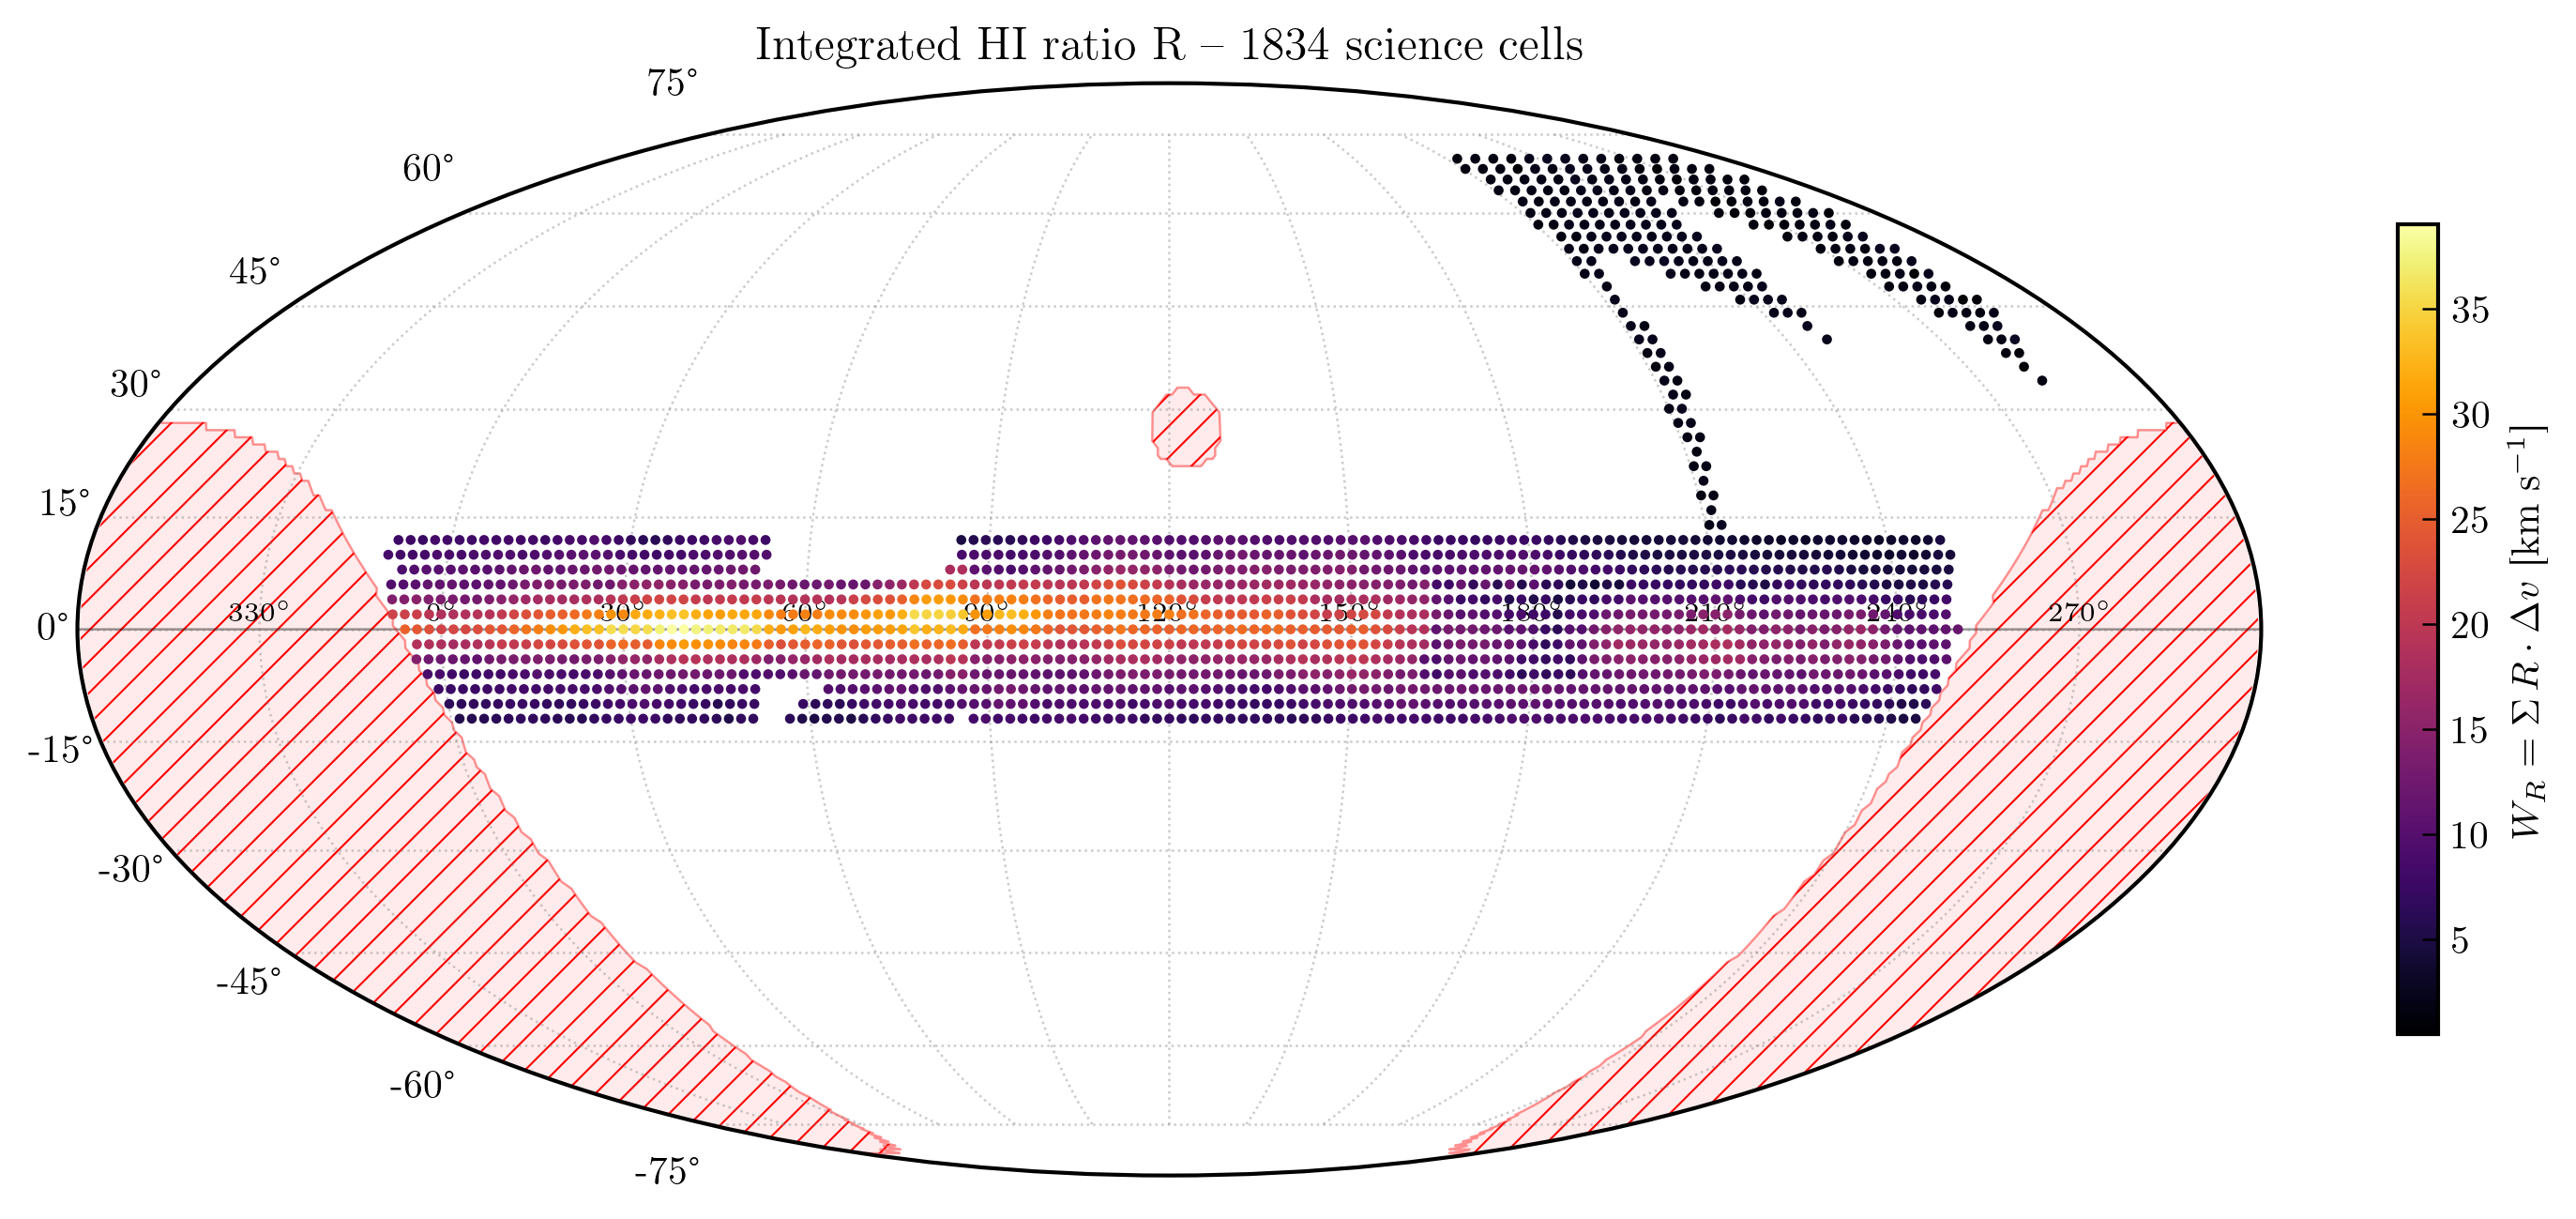

In [6]:
arrs = assemble_W_R_arrays(cell_combined, {}, set(), dv_kms)
gl_arr, gb_arr, W_R, valid_R = arrs['gl'], arrs['gb'], arrs['W_R'], arrs['valid']

fig, ax = plot_survey_mollweide(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=f'Integrated HI ratio R -- {arrs["n_sci"]} science cells',
)
plt.show()

## 6. Beam-weighted Mollweide map of integrated R

Beam-weighted resampling of `W_R(l, b)` onto a fine pixel grid. Each
pixel is a Gaussian-beam-weighted average over pointings whose 3.4 deg
HPBW partially overlaps it (cutoff at 2 * HPBW). Pixels with negligible
total weight are masked.

Units are km/s -- no temperature calibration applied.

/home/ikaros/projects/ay-121/labs/04/plotters.py:580: RuntimeWarning: invalid value encountered in divide
  img = np.where(den > min_weight, num / den, np.nan).reshape(LL.shape)


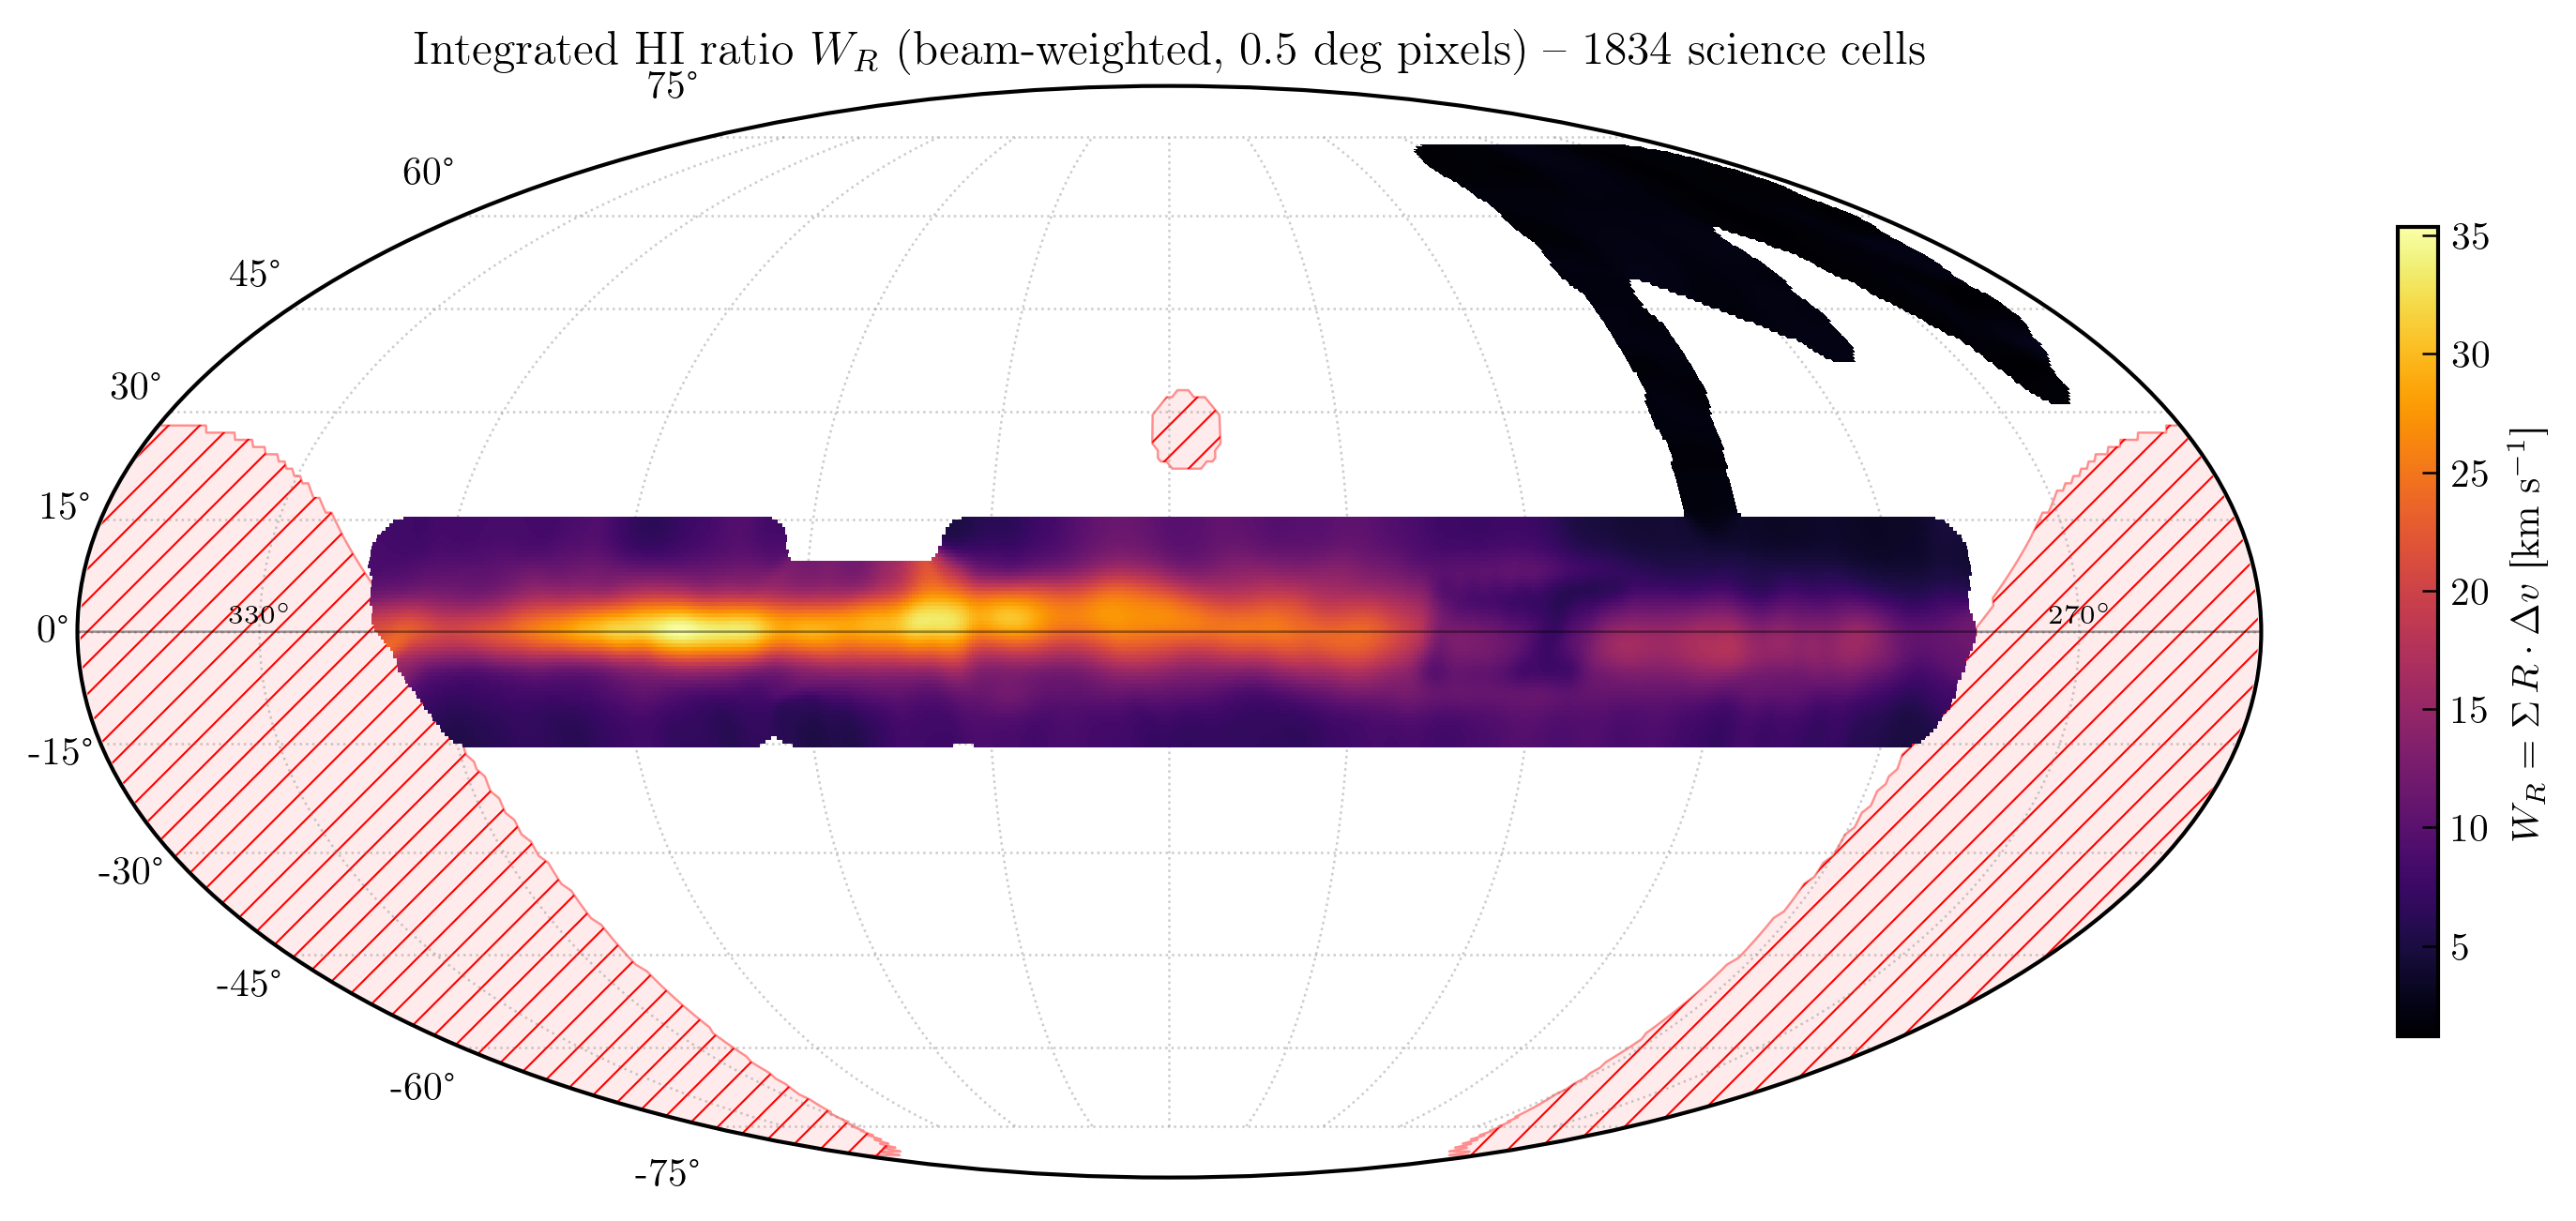

In [7]:
PIXEL_DEG = 0.5      # Mollweide pixel size (deg); finer than HPBW for smooth fill
CUTOFF_HPBW = 2.0    # include pointings within this many HPBW of each pixel center

fig, ax = plot_survey_mollweide_gridded(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=(f'Integrated HI ratio $W_R$ (beam-weighted, {PIXEL_DEG} deg pixels) -- '
           f'{arrs["n_sci"]} science cells'),
)
plt.show()

## 6b. Beam-weighted l-v strip at b ~ 0

Resample (l, b ~ 0) cells onto a fine longitude grid using a Gaussian
beam kernel (sigma = HPBW / 2.355) over all cells with `|b| <= B_MAX_DEG`.
Each (l, v) pixel is `sum(w_i R_i(v)) / sum(w_i)` over contributing
cells, with weights cut off at `CUTOFF_HPBW * HPBW` and pixels with
total weight below `MIN_WEIGHT` masked. Pixels with no cell within
`KEEP_NEAR_HPBW * HPBW` are also masked, which automatically blanks the
never-observable wedge without explicit segment bookkeeping.

The image is in the dimensionless frequency-switched ratio R(v_LSR) (no
T-calibration applied at this stage).

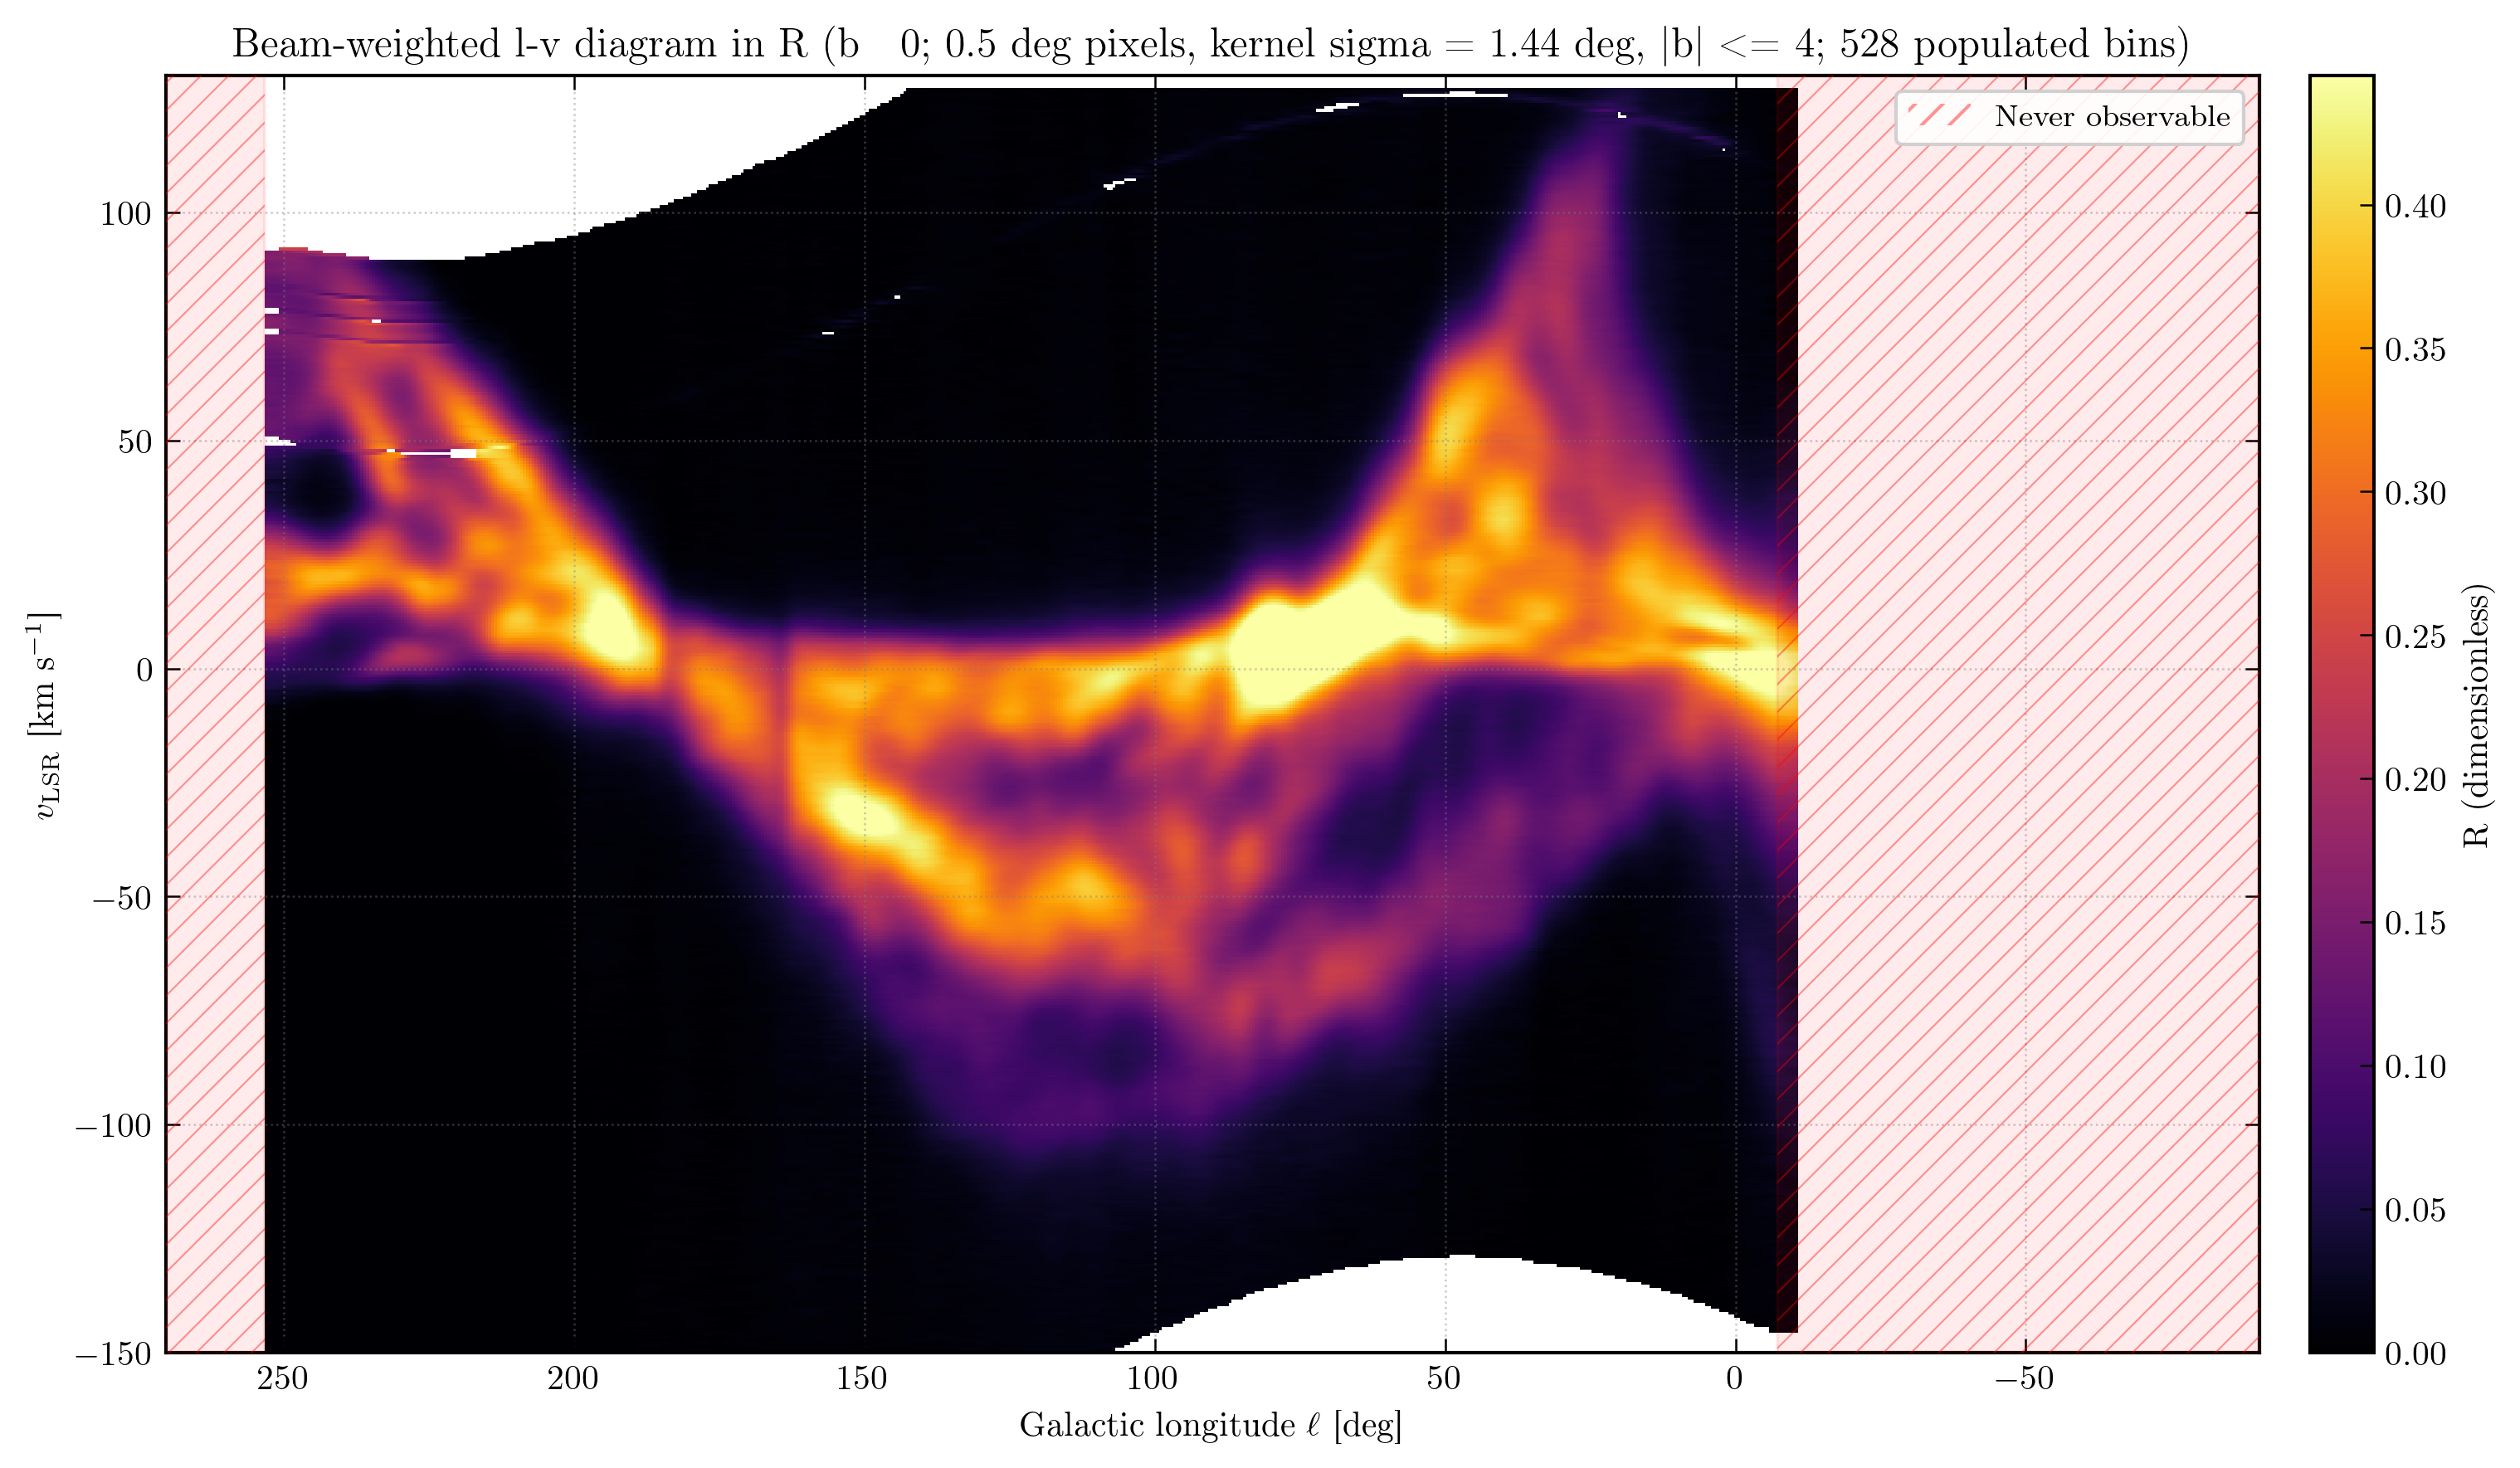

In [8]:
from utils import compute_lv_strip
from plotters import plot_lv_strip

LV_DL_FINE = 0.5
B_MAX_DEG = 4.0

strip = compute_lv_strip(
    cell_combined, cells_insufficient_pairs,
    b_max_deg=B_MAX_DEG,
    dl_fine_deg=LV_DL_FINE,
    hpbw_deg=HPBW_DEG,
    spectrum_key='R',
)

fig, ax = plot_lv_strip(
    strip['l_fine'], v_lsr_overlap, strip['lv_image'],
    title=(f"Beam-weighted l-v diagram in R (b ~ 0; "
           f"{LV_DL_FINE} deg pixels, kernel sigma = {strip['sigma_deg']:.2f} deg, "
           f"|b| <= {B_MAX_DEG:.0f}; {strip['n_populated']} populated bins)"),
    cbar_label='R (dimensionless)',
)
plt.show()

## 7. Per-cell calibration scalars (band-averaged P_on, P_off)

Cache the per-(session, cell) noise-on / noise-off band-averaged
powers needed for temperature calibration so ``main_scan_qa.ipynb``
can apply ``Tcal_pol(t)`` from
``artifacts/tcal_drift_state.pkl`` without re-touching the raw
dumps.

For each ``(session, gl, gb, lo_mhz)``, band-average
``stokes_I = corr00 + corr11`` over the LO overlap (DC excluded)
for noise-on (``cal_*``) and noise-off (``obs_*``) dumps surviving
``flag_outlier_dumps``.  Output is a tiny scalar table; QA then
computes ``T_sys = Tcal_I(t) * P_off / (P_on - P_off)`` and
``T_B = R * T_sys`` at load time.


In [9]:
from collections import defaultdict

INT_MASK = overlap_mask.copy()
INT_MASK[NFFT // 2] = False  # exclude DC bin

_bucket = defaultdict(lambda: defaultdict(list))
for r in records:
    p = np.nanmean(r['stokes_I'][INT_MASK])
    _bucket[(r['session'], r['gl'], r['gb'])][(r['lo_mhz'], r['noise_on'])].append(
        (r['time'], p)
    )

cell_scalars = {}
for scell, by_lo_noise in _bucket.items():
    times = [t for buckets in by_lo_noise.values() for t, _ in buckets]
    entry = {'t_median': np.median(times)}
    for lo_mhz in (F1_MHZ, F2_MHZ):
        on  = by_lo_noise.get((lo_mhz, True),  [])
        off = by_lo_noise.get((lo_mhz, False), [])
        P_on  = np.mean([p for _, p in on])  if on  else np.nan
        P_off = np.mean([p for _, p in off]) if off else np.nan
        entry[f'P_on_{lo_mhz:g}']  = P_on
        entry[f'P_off_{lo_mhz:g}'] = P_off
        entry[f'n_on_{lo_mhz:g}']  = len(on)
        entry[f'n_off_{lo_mhz:g}'] = len(off)
    cell_scalars[scell] = entry

print(f'Per-(session, cell) calibration scalars: {len(cell_scalars)} entries')
n_full = sum(
    1 for e in cell_scalars.values()
    if all(
        np.isfinite(e[f'P_on_{lo:g}']) and np.isfinite(e[f'P_off_{lo:g}'])
        for lo in (F1_MHZ, F2_MHZ)
    )
)
print(f'  {n_full} have on/off for both LOs (fully calibratable)')


Per-(session, cell) calibration scalars: 1890 entries
  1890 have on/off for both LOs (fully calibratable)


In [10]:
# Export state for main_scan_qa.ipynb /
# main_scan_load_diagnostics.ipynb. cell_combined entries carry
# the dimensionless ratio R(v_LSR); cell_scalars carries the
# per-(session, cell) band-averaged P_on / P_off scalars needed by
# QA to compute T_B = R * T_sys using the Tcal(t) drift state.
import pickle

state = {
    'cell_combined': cell_combined,
    'viable_pairs_per_cell': viable_pairs_per_cell,
    'cells_insufficient_pairs': cells_insufficient_pairs,
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'overlap_mask': overlap_mask,
    'int_mask': INT_MASK,
    'sessions': sessions,
    'lo_pair_mhz': (F1_MHZ, F2_MHZ),
    'cell_scalars': cell_scalars,
}
with open(STATE_PATH, 'wb') as f:
    pickle.dump(state, f)
print(f'Wrote {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(cell_combined)} science cells, '
      f'{len(cell_scalars)} cell-scalar entries')


Wrote artifacts/scan_load_state.pkl (34.90 MB) -- 1834 science cells, 1890 cell-scalar entries
